# Setup C: spiderwheel effective sample size proxy

This notebook estimates a first-order refreshed optical mass proxy for a spiderwheel-driven NIR diffuse reflectance powder interface. It is intended as a presentation-ready engineering notebook, not a radiative-transfer model or a Gy sampling-theory model.


## Scientific background

NIR diffuse reflectance probes interrogate a shallow powder layer in front of the optical window. In practical engineering studies, the optical interaction region is often approximated with a simple geometry so that motion, density, and penetration depth can be compared without a full photon-transport model.

Mechanical renewal matters because one spectrum is acquired over a finite time window. If fresh powder is repeatedly moved through the probe field during that interval, the measurement can represent a larger gross refreshed optical mass than a static bed. Setup C differs from a static powder bed and from a simple through-flow interface because a rotating spiderwheel actively sweeps powder through the local probe region. The same geometry can also periodically block the optical window when a finger passes the probe.


## Setup C device description

The device is modeled as a 4-legged spiderwheel centered in a powder stream. The NIR probe sits at the true 1 o'clock position relative to the wheel center, with a fixed probe window diameter of 5 mm. The fingers move powder through the field of view, but when a finger overlaps the probe region the window is treated as fully blocked. This notebook uses a first-order mechanistic approximation based on the wheel geometry conventions used in `spiderwheel.ipynb`.


## Model assumptions

- Optical sampling volume is approximated as a cylinder.
- Optical mass per refresh equals probe footprint area times penetration depth times bulk density.
- Powder renewal is approximated from tangential wheel motion at the probe radius.
- Wheel fingers block the probe during overlap intervals.
- Blocked time is subtracted from total acquisition time.
- Bulk density is constant and spatially uniform.
- Powder re-presentation and recirculation are ignored.
- Binary blocking is assumed rather than partial attenuation.
- Output is a refresh-based effective sample size proxy, not a validated independent sample mass.


## Mathematical model

$$\omega = \frac{2\pi \cdot \mathrm{RPM}}{60}$$
$$\theta_{\mathrm{probe}} = 30^\circ = \frac{\pi}{6}$$
$$v = \omega r$$
$$A_{\mathrm{probe}} = \pi \left(\frac{d_{\mathrm{probe}}}{2}\right)^2$$
$$V_{\mathrm{opt}} = A_{\mathrm{probe}} \cdot d_{\mathrm{pen}}$$
$$m_{\mathrm{opt}} = \rho \cdot V_{\mathrm{opt}}$$
$$t_{\mathrm{cross}} = \frac{d_{\mathrm{probe}}}{v}$$
$$t_{\mathrm{eff}} = t_{\mathrm{acq}} - t_{\mathrm{blocked}}$$
$$N_{\mathrm{refresh}} = \frac{t_{\mathrm{eff}}}{t_{\mathrm{cross}}}$$
$$m_{\mathrm{eff,proxy}} = m_{\mathrm{opt}} \cdot N_{\mathrm{refresh}}$$

Blocked time is estimated from a combined angular overlap of finger width and probe width at the probe radius. The result is best interpreted as a gross refreshed optical mass proxy during one spectrum.


## Imports


In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.4f}'.format


## User-defined parameters


In [2]:
n_fingers = 4  # [-]
wheel_radius_cm = 3.0  # [cm]
probe_radius_cm = 1.8  # [cm], reused from the old spiderwheel geometry style
finger_width_cm = 0.3  # [cm], tangential width at probe radius
probe_diameter_mm = 5.0  # [mm]
acquisition_time_s = 1.0  # [s]
density_values_g_cm3 = [0.4, 0.5, 0.6]
rpm_values = list(range(10, 36))
penetration_depth_values_mm = np.round(np.arange(0.1, 2.0 + 0.1, 0.1), 1)
probe_angle_rad = np.pi / 6.0  # true 1 o'clock
probe_diameter_cm = probe_diameter_mm / 10.0
example_density_g_cm3 = 0.5
example_rpm = 20
example_penetration_depth_mm = 1.0


## Helper functions


In [3]:
def _pos(name, value, allow_zero=False):
    value = float(value)
    if allow_zero and value < 0:
        raise ValueError(f'{name} must be non-negative.')
    if not allow_zero and value <= 0:
        raise ValueError(f'{name} must be positive.')
    return value

def rpm_to_angular_speed(rpm):
    """Convert RPM to angular speed in rad/s."""
    return 2 * math.pi * _pos('rpm', rpm, allow_zero=True) / 60

def probe_position_1oclock(radius_cm):
    """Return the probe-center coordinates at 1 o'clock."""
    r = _pos('radius_cm', radius_cm)
    return r * math.cos(math.pi / 6), r * math.sin(math.pi / 6)

def probe_area_cm2(probe_diameter_cm):
    """Return circular probe area in cm^2."""
    d = _pos('probe_diameter_cm', probe_diameter_cm)
    return math.pi * (d / 2) ** 2

def optical_volume_cm3(probe_diameter_cm, penetration_depth_cm):
    """Return cylindrical optical volume in cm^3."""
    return probe_area_cm2(probe_diameter_cm) * _pos('penetration_depth_cm', penetration_depth_cm)

def optical_mass_g(density_g_cm3, probe_diameter_cm, penetration_depth_cm):
    """Return optical mass per refresh in g."""
    return _pos('density_g_cm3', density_g_cm3) * optical_volume_cm3(probe_diameter_cm, penetration_depth_cm)

def tangential_velocity_cm_s(rpm, probe_radius_cm):
    """Return tangential velocity at the probe radius in cm/s."""
    return rpm_to_angular_speed(rpm) * _pos('probe_radius_cm', probe_radius_cm)

def crossing_time_s(probe_diameter_cm, tangential_velocity_value_cm_s):
    """Return time to traverse one probe diameter."""
    return _pos('probe_diameter_cm', probe_diameter_cm) / _pos('tangential_velocity_value_cm_s', tangential_velocity_value_cm_s)

def estimate_blocked_time_s(rpm, acquisition_time_s, n_fingers, finger_width_cm, probe_radius_cm, probe_diameter_cm):
    """Estimate total blocked time using a simple overlap-angle model."""
    rpm = _pos('rpm', rpm, allow_zero=True)
    t_acq = _pos('acquisition_time_s', acquisition_time_s)
    n_fingers = int(_pos('n_fingers', n_fingers))
    w = _pos('finger_width_cm', finger_width_cm)
    r = _pos('probe_radius_cm', probe_radius_cm)
    d_probe = _pos('probe_diameter_cm', probe_diameter_cm)
    if rpm == 0:
        return 0.0
    omega = rpm_to_angular_speed(rpm)
    overlap_angle = (w / r) + (d_probe / r)
    blocked_per_pass = overlap_angle / omega
    passes = math.ceil(t_acq * rpm * n_fingers / 60.0)
    return min(t_acq, passes * blocked_per_pass)

def effective_sample_mass_proxy_mg(density_g_cm3, probe_diameter_cm, penetration_depth_cm, rpm, acquisition_time_s, probe_radius_cm, n_fingers, finger_width_cm):
    """Return refreshed optical mass proxy in mg for one acquisition."""
    m_opt_g = optical_mass_g(density_g_cm3, probe_diameter_cm, penetration_depth_cm)
    v = tangential_velocity_cm_s(rpm, probe_radius_cm)
    if v <= 0:
        return 0.0
    t_cross = crossing_time_s(probe_diameter_cm, v)
    t_block = estimate_blocked_time_s(rpm, acquisition_time_s, n_fingers, finger_width_cm, probe_radius_cm, probe_diameter_cm)
    t_eff = max(acquisition_time_s - t_block, 0.0)
    n_refresh = t_eff / t_cross if t_cross > 0 else 0.0
    return m_opt_g * n_refresh * 1000.0


## Single-case worked example


In [4]:
example_penetration_depth_cm = example_penetration_depth_mm / 10.0
omega = rpm_to_angular_speed(example_rpm)
probe_x_cm, probe_y_cm = probe_position_1oclock(probe_radius_cm)
area_cm2 = probe_area_cm2(probe_diameter_cm)
volume_cm3 = optical_volume_cm3(probe_diameter_cm, example_penetration_depth_cm)
mass_g = optical_mass_g(example_density_g_cm3, probe_diameter_cm, example_penetration_depth_cm)
velocity_cm_s = tangential_velocity_cm_s(example_rpm, probe_radius_cm)
t_cross = crossing_time_s(probe_diameter_cm, velocity_cm_s)
t_block = estimate_blocked_time_s(example_rpm, acquisition_time_s, n_fingers, finger_width_cm, probe_radius_cm, probe_diameter_cm)
t_eff = max(acquisition_time_s - t_block, 0.0)
n_refresh = t_eff / t_cross if t_cross > 0 else 0.0
m_eff_proxy_mg = effective_sample_mass_proxy_mg(example_density_g_cm3, probe_diameter_cm, example_penetration_depth_cm, example_rpm, acquisition_time_s, probe_radius_cm, n_fingers, finger_width_cm)
worked_example_df = pd.DataFrame({'quantity':['angular speed','probe x','probe y','probe area','optical volume per refresh','optical mass per refresh','tangential velocity','crossing time','blocked time','effective acquisition time','estimated number of refreshes','effective sample size proxy'],'value':[omega,probe_x_cm,probe_y_cm,area_cm2,volume_cm3,mass_g*1000.0,velocity_cm_s,t_cross,t_block,t_eff,n_refresh,m_eff_proxy_mg],'units':['rad/s','cm','cm','cm^2','cm^3','mg','cm/s','s','s','s','-','mg']})
worked_example_df


,quantity,value,units
0,angular speed,2.0944,rad/s
1,probe x,1.5588,cm
2,probe y,0.9000,cm
3,probe area,0.1963,cm^2
4,optical volume per refresh,0.0196,cm^3
5,optical mass per refresh,9.8175,mg
6,tangential velocity,3.7699,cm/s
7,crossing time,0.1326,s
8,blocked time,0.4244,s
9,effective acquisition time,0.5756,s


## Parameter sweep across density, RPM, and penetration depth


In [5]:
rows = []
for density in density_values_g_cm3:
    for rpm in rpm_values:
        omega = rpm_to_angular_speed(rpm)
        velocity = tangential_velocity_cm_s(rpm, probe_radius_cm)
        t_cross = crossing_time_s(probe_diameter_cm, velocity)
        t_block = estimate_blocked_time_s(rpm, acquisition_time_s, n_fingers, finger_width_cm, probe_radius_cm, probe_diameter_cm)
        t_eff = max(acquisition_time_s - t_block, 0.0)
        for depth_mm in penetration_depth_values_mm:
            depth_cm = float(depth_mm) / 10.0
            m_refresh_mg = optical_mass_g(density, probe_diameter_cm, depth_cm) * 1000.0
            n_refresh = t_eff / t_cross if t_cross > 0 else 0.0
            rows.append({'density_g_cm3':float(density),'rpm':int(rpm),'penetration_depth_mm':float(depth_mm),'probe_diameter_mm':float(probe_diameter_mm),'acquisition_time_s':float(acquisition_time_s),'angular_speed_rad_s':omega,'tangential_velocity_cm_s':velocity,'crossing_time_s':t_cross,'blocked_time_s':t_block,'effective_time_s':t_eff,'optical_mass_per_refresh_mg':m_refresh_mg,'n_refresh':n_refresh,'effective_sample_mass_proxy_mg':m_refresh_mg * n_refresh})
results_df = pd.DataFrame(rows)
results_df.head()


,density_g_cm3,rpm,penetration_depth_mm,probe_diameter_mm,acquisition_time_s,angular_speed_rad_s,tangential_velocity_cm_s,crossing_time_s,blocked_time_s,effective_time_s,optical_mass_per_refresh_mg,n_refresh,effective_sample_mass_proxy_mg
0,0.4000,10,0.1000,5.0000,1.0000,1.0472,1.8850,0.2653,0.4244,0.5756,0.7854,2.1699,1.7042
1,0.4000,10,0.2000,5.0000,1.0000,1.0472,1.8850,0.2653,0.4244,0.5756,1.5708,2.1699,3.4085
2,0.4000,10,0.3000,5.0000,1.0000,1.0472,1.8850,0.2653,0.4244,0.5756,2.3562,2.1699,5.1127
3,0.4000,10,0.4000,5.0000,1.0000,1.0472,1.8850,0.2653,0.4244,0.5756,3.1416,2.1699,6.8170
4,0.4000,10,0.5000,5.0000,1.0000,1.0472,1.8850,0.2653,0.4244,0.5756,3.9270,2.1699,8.5212


## Results tables


In [6]:
selected_summary_df = results_df[(results_df['rpm'].isin([10, 20, 35])) & (results_df['penetration_depth_mm'].isin([0.5, 1.0, 2.0]))].copy()
selected_summary_df[['density_g_cm3','rpm','penetration_depth_mm','blocked_time_s','n_refresh','optical_mass_per_refresh_mg','effective_sample_mass_proxy_mg']].reset_index(drop=True)


,density_g_cm3,rpm,penetration_depth_mm,blocked_time_s,n_refresh,optical_mass_per_refresh_mg,effective_sample_mass_proxy_mg
0,0.4000,10,0.5000,0.4244,2.1699,3.9270,8.5212
1,0.4000,10,1.0000,0.4244,2.1699,7.8540,17.0424
2,0.4000,10,2.0000,0.4244,2.1699,15.7080,34.0849
3,0.4000,20,0.5000,0.4244,4.3398,3.9270,17.0424
4,0.4000,20,1.0000,0.4244,4.3398,7.8540,34.0849
5,0.4000,20,2.0000,0.4244,4.3398,15.7080,68.1698
6,0.4000,35,0.5000,0.3638,8.3947,3.9270,32.9659
7,0.4000,35,1.0000,0.3638,8.3947,7.8540,65.9317
8,0.4000,35,2.0000,0.3638,8.3947,15.7080,131.8635
9,0.5000,10,0.5000,0.4244,2.1699,4.9087,10.6515


In [7]:
heatmap_05_df = results_df[results_df['density_g_cm3'] == 0.5].pivot(index='penetration_depth_mm', columns='rpm', values='effective_sample_mass_proxy_mg')
heatmap_06_df = results_df[results_df['density_g_cm3'] == 0.6].pivot(index='penetration_depth_mm', columns='rpm', values='effective_sample_mass_proxy_mg')
heatmap_05_df.iloc[:6, :6]


rpm,10,11,12,13,14,15
penetration_depth_mm,,,,,,
0.1000,2.1303,2.5004,2.8705,3.2406,3.6107,3.9809
0.2000,4.2606,5.0008,5.7411,6.4813,7.2215,7.9617
0.3000,6.3909,7.5012,8.6116,9.7219,10.8322,11.9426
0.4000,8.5212,10.0017,11.4821,12.9625,14.4430,15.9234
0.5000,10.6515,12.5021,14.3526,16.2032,18.0537,19.9043
0.6000,12.7818,15.0025,17.2232,19.4438,21.6645,23.8851


## Visualization

The blocking model assumes full blocking when a finger overlaps the probe region; it does not model partial attenuation.


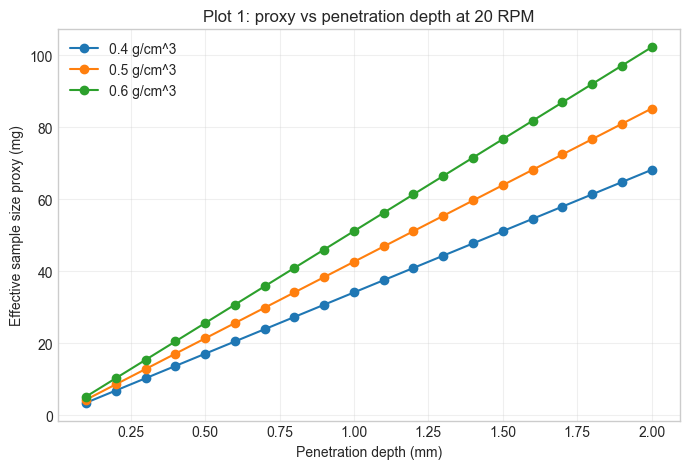

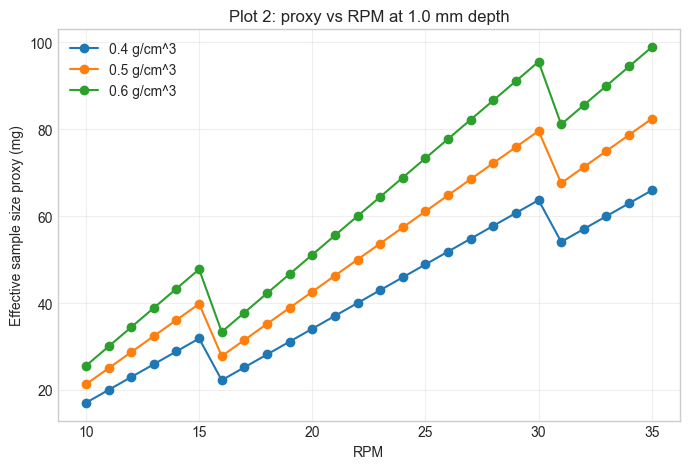

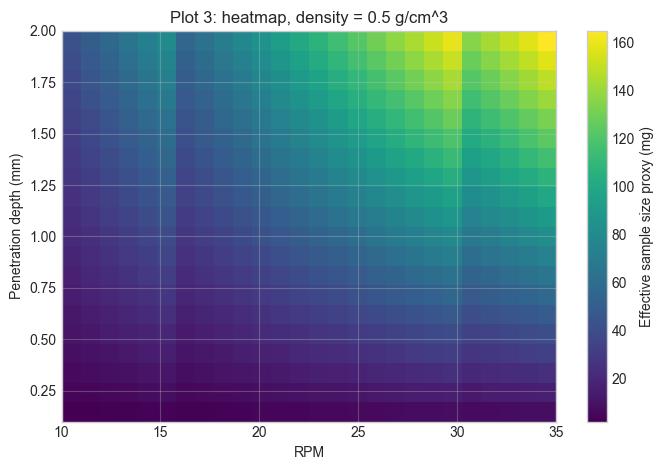

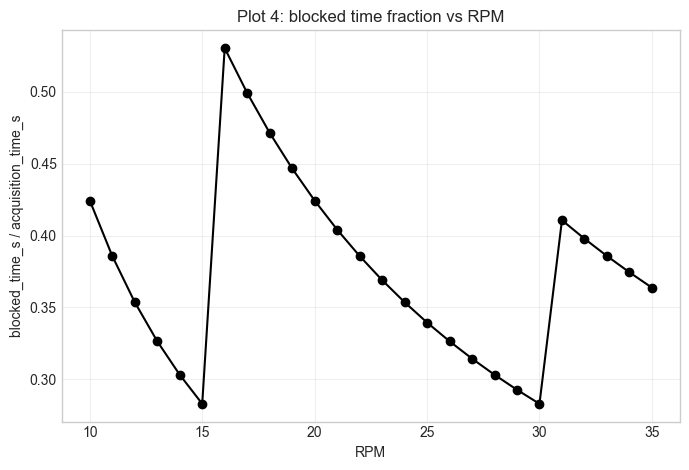

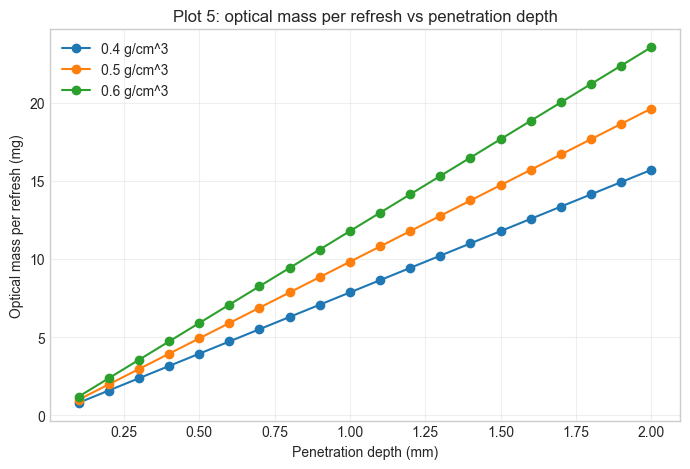

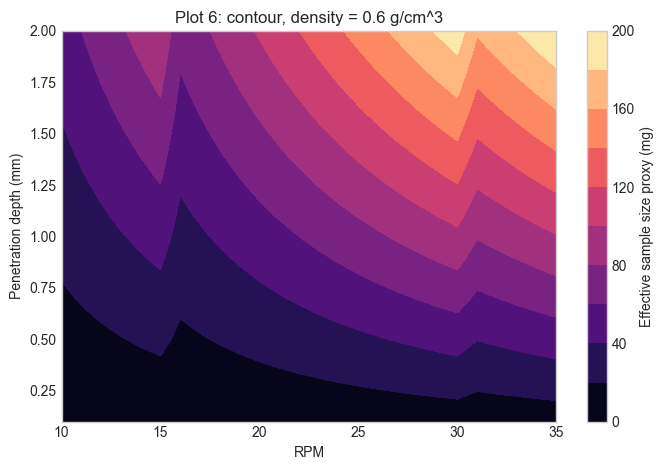

In [8]:
plot1_df = results_df[results_df['rpm'] == 20]
plot2_df = results_df[np.isclose(results_df['penetration_depth_mm'], 1.0)]
bf = results_df[['rpm', 'blocked_time_s', 'acquisition_time_s']].drop_duplicates().sort_values('rpm')
rpm_grid, depth_grid = np.meshgrid(heatmap_06_df.columns.values, heatmap_06_df.index.values)

fig_setup_c_plot_01, ax = plt.subplots(figsize=(7, 4.8))
for density in density_values_g_cm3:
    s = plot1_df[plot1_df['density_g_cm3'] == density]
    ax.plot(s['penetration_depth_mm'], s['effective_sample_mass_proxy_mg'], marker='o', label=f'{density:.1f} g/cm^3')
ax.set_title('Plot 1: proxy vs penetration depth at 20 RPM')
ax.set_xlabel('Penetration depth (mm)')
ax.set_ylabel('Effective sample size proxy (mg)')
ax.grid(True, alpha=0.3)
ax.legend()
fig_setup_c_plot_01.tight_layout()
plt.show()

fig_setup_c_plot_02, ax = plt.subplots(figsize=(7, 4.8))
for density in density_values_g_cm3:
    s = plot2_df[plot2_df['density_g_cm3'] == density]
    ax.plot(s['rpm'], s['effective_sample_mass_proxy_mg'], marker='o', label=f'{density:.1f} g/cm^3')
ax.set_title('Plot 2: proxy vs RPM at 1.0 mm depth')
ax.set_xlabel('RPM')
ax.set_ylabel('Effective sample size proxy (mg)')
ax.grid(True, alpha=0.3)
ax.legend()
fig_setup_c_plot_02.tight_layout()
plt.show()

fig_setup_c_plot_03, ax = plt.subplots(figsize=(7, 4.8))
im1 = ax.imshow(
    heatmap_05_df.values,
    aspect='auto',
    origin='lower',
    extent=[heatmap_05_df.columns.min(), heatmap_05_df.columns.max(), heatmap_05_df.index.min(), heatmap_05_df.index.max()],
    cmap='viridis',
)
ax.set_title('Plot 3: heatmap, density = 0.5 g/cm^3')
ax.set_xlabel('RPM')
ax.set_ylabel('Penetration depth (mm)')
ax.grid(True, alpha=0.3)
fig_setup_c_plot_03.colorbar(im1, ax=ax, label='Effective sample size proxy (mg)')
fig_setup_c_plot_03.tight_layout()
plt.show()

fig_setup_c_plot_04, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(bf['rpm'], bf['blocked_time_s'] / bf['acquisition_time_s'], marker='o', color='black')
ax.set_title('Plot 4: blocked time fraction vs RPM')
ax.set_xlabel('RPM')
ax.set_ylabel('blocked_time_s / acquisition_time_s')
ax.grid(True, alpha=0.3)
fig_setup_c_plot_04.tight_layout()
plt.show()

fig_setup_c_plot_05, ax = plt.subplots(figsize=(7, 4.8))
for density in density_values_g_cm3:
    s = plot1_df[plot1_df['density_g_cm3'] == density]
    ax.plot(s['penetration_depth_mm'], s['optical_mass_per_refresh_mg'], marker='o', label=f'{density:.1f} g/cm^3')
ax.set_title('Plot 5: optical mass per refresh vs penetration depth')
ax.set_xlabel('Penetration depth (mm)')
ax.set_ylabel('Optical mass per refresh (mg)')
ax.grid(True, alpha=0.3)
ax.legend()
fig_setup_c_plot_05.tight_layout()
plt.show()

fig_setup_c_plot_06, ax = plt.subplots(figsize=(7, 4.8))
im2 = ax.contourf(rpm_grid, depth_grid, heatmap_06_df.values, levels=12, cmap='magma')
ax.set_title('Plot 6: contour, density = 0.6 g/cm^3')
ax.set_xlabel('RPM')
ax.set_ylabel('Penetration depth (mm)')
ax.grid(True, alpha=0.3)
fig_setup_c_plot_06.colorbar(im2, ax=ax, label='Effective sample size proxy (mg)')
fig_setup_c_plot_06.tight_layout()
plt.show()


## Interpretation of trends

Increasing density increases mass linearly. Increasing penetration depth increases optical mass per refresh linearly in this simplified model. Increasing RPM decreases crossing time and tends to increase refresh count, while blocking reduces effective acquisition time and partially offsets that gain. The output is a refreshed optical mass proxy, not necessarily an independent sampling mass.


## Model limitations

- Cylindrical optical volume is only an approximation.
- No radiative transfer or photon weighting with depth.
- No powder recirculation or revisit probability.
- No correction for repeated presentation of the same powder.
- Binary blocking rather than partial attenuation.
- Constant bulk density assumption.
- No particle size or particle count model.
- Not linked directly to analytical variance or Gy sampling theory.


## Conclusions

The notebook estimates a first-order refreshed optical mass proxy for Setup C. Density, penetration depth, RPM, probe size, and blocking geometry strongly influence the result. This is useful for sensitivity analysis and engineering intuition, while future improvements could include phase-resolved blocking, revisit probability, partial blocking, and more realistic optical weighting.


## Export and Reporting

This export section writes timestamped CSV, PNG, JSON, and Word outputs into the setup-specific `reports/` folder. `python-docx` and `nbformat` are required for Word export with Markdown rendering.

In [9]:
from pathlib import Path
import importlib
import sys

# Resolve project root dynamically (notebooks live in <project>/notebooks/)
try:
    project_root = Path(__vsc_ipynb_file__).resolve().parent.parent
except NameError:
    project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.reporting_utils as reporting_utils
reporting_utils = importlib.reload(reporting_utils)

build_word_report = reporting_utils.build_word_report
create_run_directory = reporting_utils.create_run_directory
save_dataframes_dict = reporting_utils.save_dataframes_dict
save_figures_dict = reporting_utils.save_figures_dict
write_metadata_json = reporting_utils.write_metadata_json

setup_name = "setup_c"
notebook_filename = "setup_C_spiderwheel_effective_sample_size.ipynb"
notebook_path = project_root / "notebooks" / notebook_filename
report_filename = "setup_c_report.docx"

timestamp, run_dir = create_run_directory(project_root, setup_name)

summary_table_df = selected_summary_df.copy()
blocking_summary_df = (
    results_df[["rpm", "blocked_time_s", "effective_time_s", "n_refresh"]]
    .drop_duplicates()
    .sort_values("rpm")
    .reset_index(drop=True)
)

dataframes_to_save = {
    "results_full": results_df,
    "summary_table": summary_table_df,
    "blocking_summary": blocking_summary_df,
}
figures_to_save = {
    "plot_01_proxy_vs_penetration_depth": globals().get("fig_setup_c_plot_01"),
    "plot_02_proxy_vs_rpm": globals().get("fig_setup_c_plot_02"),
    "plot_03_heatmap_density_05": globals().get("fig_setup_c_plot_03"),
    "plot_04_blocked_time_fraction_vs_rpm": globals().get("fig_setup_c_plot_04"),
    "plot_05_optical_mass_per_refresh": globals().get("fig_setup_c_plot_05"),
    "plot_06_contour_density_06": globals().get("fig_setup_c_plot_06"),
}

csv_files = save_dataframes_dict(dataframes_to_save, run_dir)
png_files = save_figures_dict(figures_to_save, run_dir, dpi=300)

parameter_summary = {
    "Finger count": int(n_fingers),
    "Wheel radius (cm)": wheel_radius_cm,
    "Probe radius (cm)": probe_radius_cm,
    "Finger width (cm)": finger_width_cm,
    "Probe diameter (mm)": probe_diameter_mm,
    "Acquisition time (s)": acquisition_time_s,
    "Density scenarios (g/cm^3)": [float(x) for x in density_values_g_cm3],
    "RPM range": f"{min(rpm_values)} to {max(rpm_values)}",
    "Penetration depth range (mm)": f"{penetration_depth_values_mm.min():.1f} to {penetration_depth_values_mm.max():.1f}",
}
purpose_text = (
    "Setup C estimates a refreshed optical mass proxy for a spiderwheel presentation by combining optical mass "
    "per refresh with a refresh count derived from wheel speed and blocked acquisition time."
)
assumptions_text = (
    "Uniform bulk density, full blocking simplification for wheel fingers, cylindrical optical sampling volume, "
    "and deterministic refresh counting without revisit or partial-blocking corrections."
)
metadata = {
    "setup_name": setup_name,
    "timestamp": timestamp,
    "notebook_filename": notebook_filename,
    "report_filename": report_filename,
    "csv_files": csv_files,
    "png_files": png_files,
    "key_parameters": parameter_summary,
}
write_metadata_json(metadata, run_dir / "metadata.json")

build_word_report(
    report_title="Setup C Effective Sample Size Report",
    setup_name=setup_name,
    timestamp=timestamp,
    run_dir=run_dir,
    notebook_path=notebook_path,
    purpose_text=purpose_text,
    assumptions_text=assumptions_text,
    parameter_summary=parameter_summary,
    csv_filenames=csv_files,
    figure_filenames=png_files,
    output_filename=report_filename,
)

print(f"Report run directory: {run_dir}")


Report run directory: C:\temp files\EFS\reports\setup_c\20260317_112459
